# Benchmark Raw GEx
Benchmark using as baseline raw GEx

# 0. Load Data

In [1]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
run_dir = os.path.join("..","..","outputs","run-25-09-03-01") # A 
output_dir = os.path.join(run_dir, "outputs")


if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-08-14-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: random
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do
scgpt_pp: norm_log1p
description: log1CPM, Counts norm. ; 3.5k genes Presence + Variance ; 50 Disease Families


In [2]:
split_idx = 0

# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

## 0.2 Load DO Pairs

In [3]:
"""0.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (8515, 8)
Nº of significant pairs in dataset (top 5% IC): (1015, 8)
Nº of significant pairs in dataset (top 1% IC): (382, 8)
Nº of negative pairs in dataset (outside 5%): (7500, 8)


# 1. Compute Similarity Matrixes

In [4]:
"""Compute similarity matrixes
"""

# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
# variable
split_idx = 0

# functions


# 2. Load Data
# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  


X_train = adata_train.X
X_train = np.where(np.isnan(X_train), 0, X_train)
X_valid = adata_valid.X
X_valid = np.where(np.isnan(X_valid), 0, X_valid)
X_test = adata_test.X
X_test = np.where(np.isnan(X_test), 0, X_test)

# compute correlation similarity between all embeddings
c_matrix_train =1 -  cdist(X_train, X_train, "correlation")
c_matrix_valid =1 -  cdist(X_valid, X_valid, "correlation")
c_matrix_test =1 -  cdist(X_test, X_test, "correlation")

# compute correlation similarity between sets
c_matrix_test_vs_train =1 -  cdist(X_test, X_train, "correlation")
c_matrix_valid_vs_train =1 - cdist(X_valid, X_train, "correlation")

In [15]:
np.argwhere(np.isnan(c_matrix_test))

array([[    0,  3830],
       [    0,  3831],
       [    0,  3832],
       ...,
       [11330,  3918],
       [11330,  3919],
       [11330,  3920]])

In [18]:
cdist(X_test[0, :].reshape(1, -1), X_test[3830, :].reshape(1, -1), "correlation")

array([[nan]])

In [20]:
(X_test[3830, :])

0.0

# 2. Benchmark Disease vs Control Similarity

In [5]:
import importlib
importlib.reload(vz)

df_train = adata_train.obs.copy()
df_test = adata_test.obs.copy()
df_valid = adata_valid.obs.copy()

df_all = pd.concat([df_train, df_valid, df_test], axis=0)
df_all = df_all.query("doid_id != 'Control'")

dsaid_2_dis = dict(zip(df_all["dsaid"], df_all["doid_id"]))

In [6]:
"""2. Benchmark Disease vs Control Similarity

Structure:
    1. Imports, Variables, Functions
    2. Get Similarity
    3. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports
from tqdm import tqdm
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# variables


# functions
# 2. Get Similarity
# define sets of related & unrelated 
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# train set
# same disease pairs
(tr_s_same_same,tr_s_same_diff,tr_s_ctrl_same, tr_s_ctrl_diff), (tr_w_same_same, tr_w_same_diff, tr_w_ctrl_same, tr_w_ctrl_diff) = vz.get_same_disease_sim(adata_train.obs, c_matrix_train)

# get unrelated pairs
tr_s_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=10000,
    seed=42,
)

# validation set
(vl_s_same_diff, vl_s_ctrl_diff), ( vl_w_same_diff, vl_w_ctrl_diff) = vz.get_same_dis_similarity_splits(adata_valid, adata_train, c_matrix_valid_vs_train,dsaid_2_dis)
vl_s_unr,_,_ = vz.get_unrelated_pairs_split_2(adata_valid, adata_train, c_matrix_valid_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)



# test set
(ts_s_same_diff, ts_s_ctrl_diff), ( ts_w_same_diff, ts_w_ctrl_diff) = vz.get_same_dis_similarity_splits(adata_test, adata_train, c_matrix_test_vs_train,dsaid_2_dis)
ts_s_unr,_,_ =vz.get_unrelated_pairs_split_2(adata_test, adata_train, c_matrix_test_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)




Processing same disease pairs: 100%|██████████| 132/132 [00:12<00:00, 10.93it/s]


132 diseases in dataset


8646it [00:23, 367.49it/s]


179501386 unrelated pairs found
10000
Selected 10000 unrelated pairs
Sampled pairs: 10000


100%|██████████| 7500/7500 [07:15<00:00, 17.21it/s] 


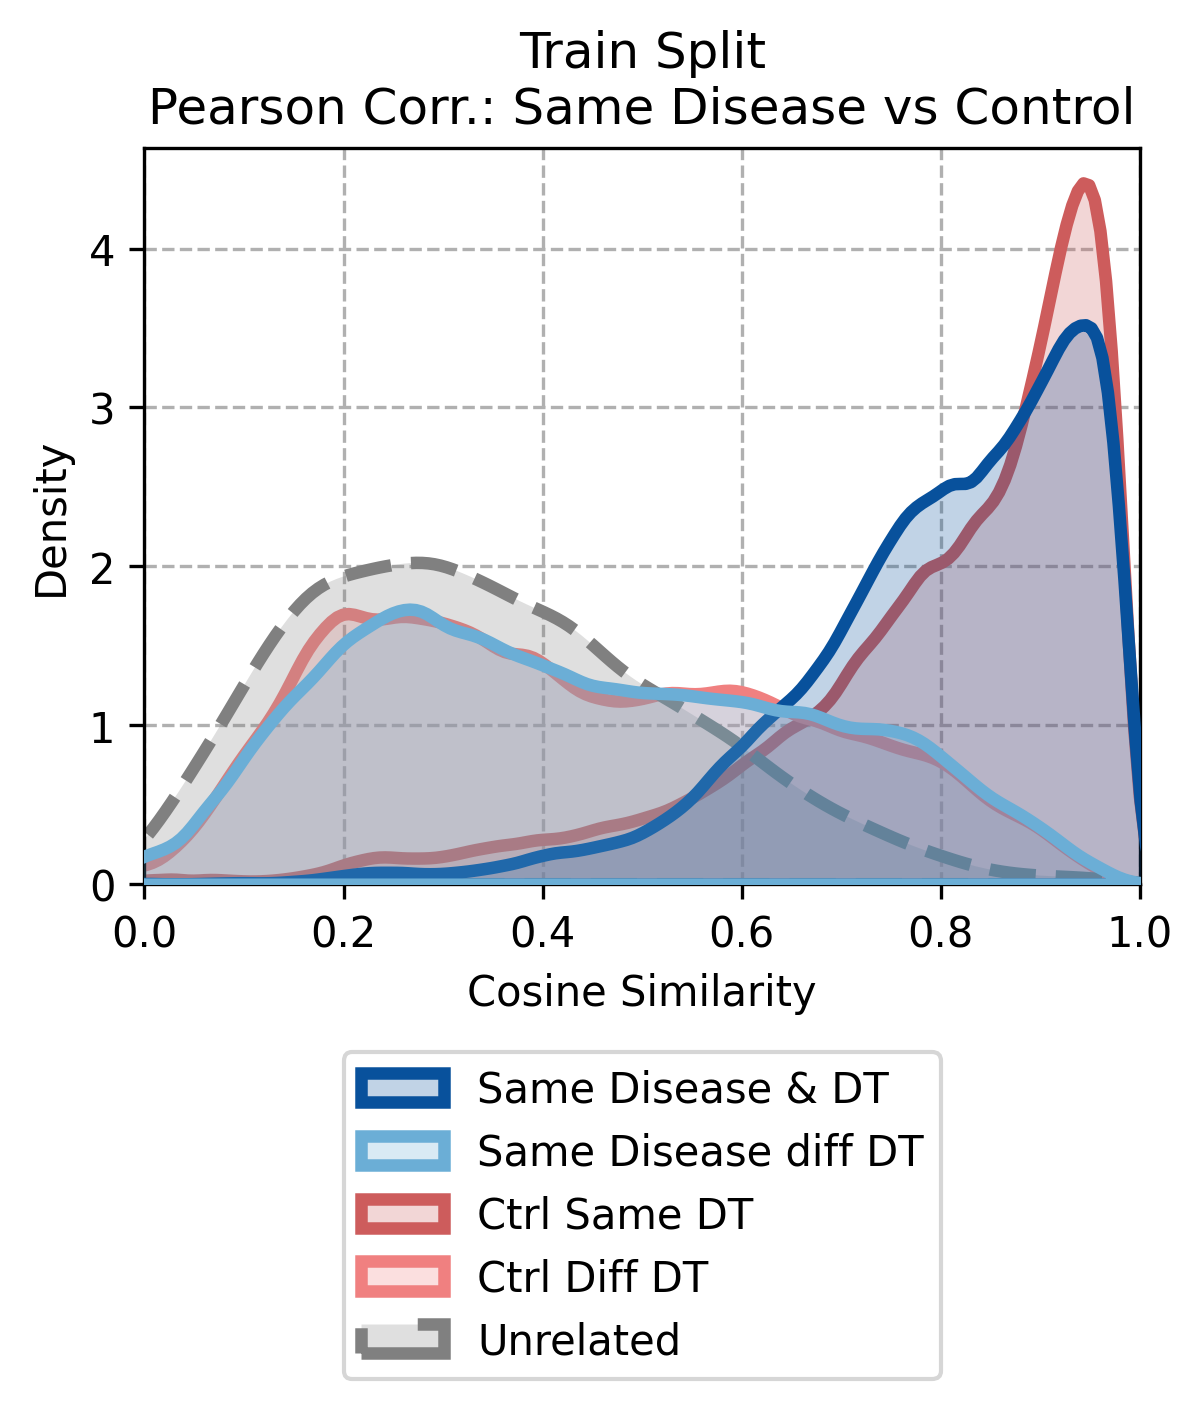

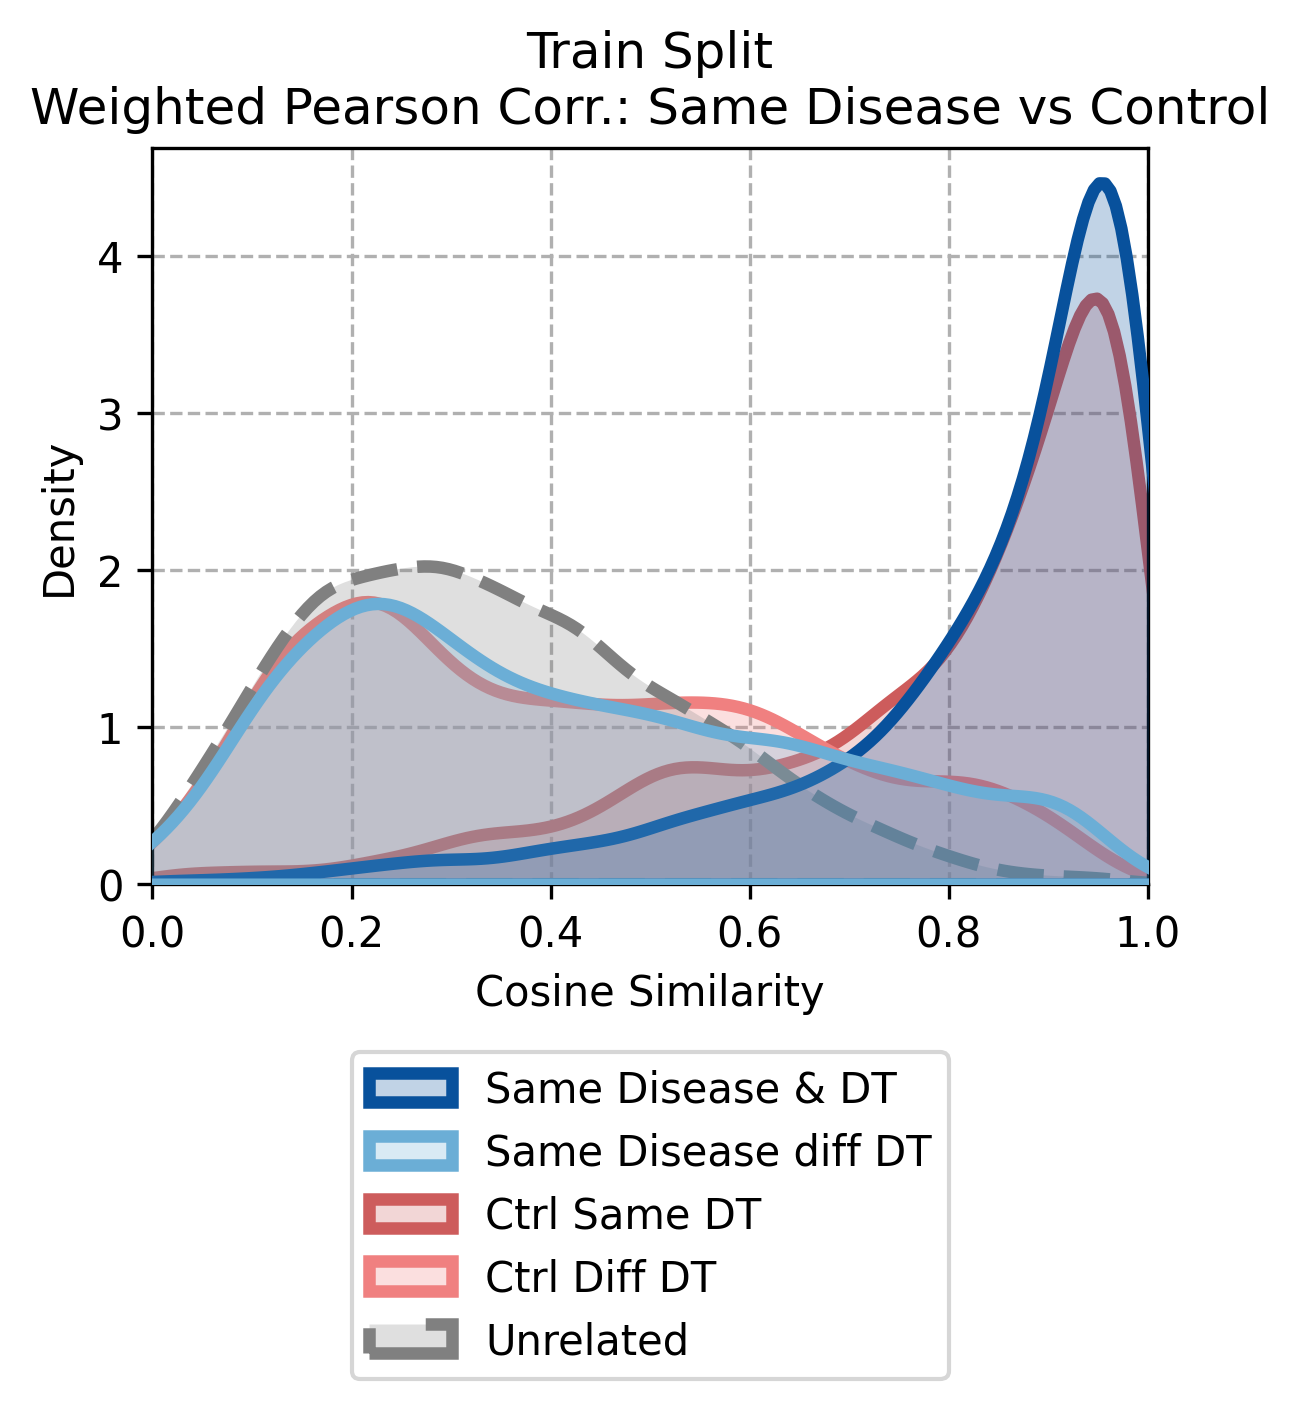

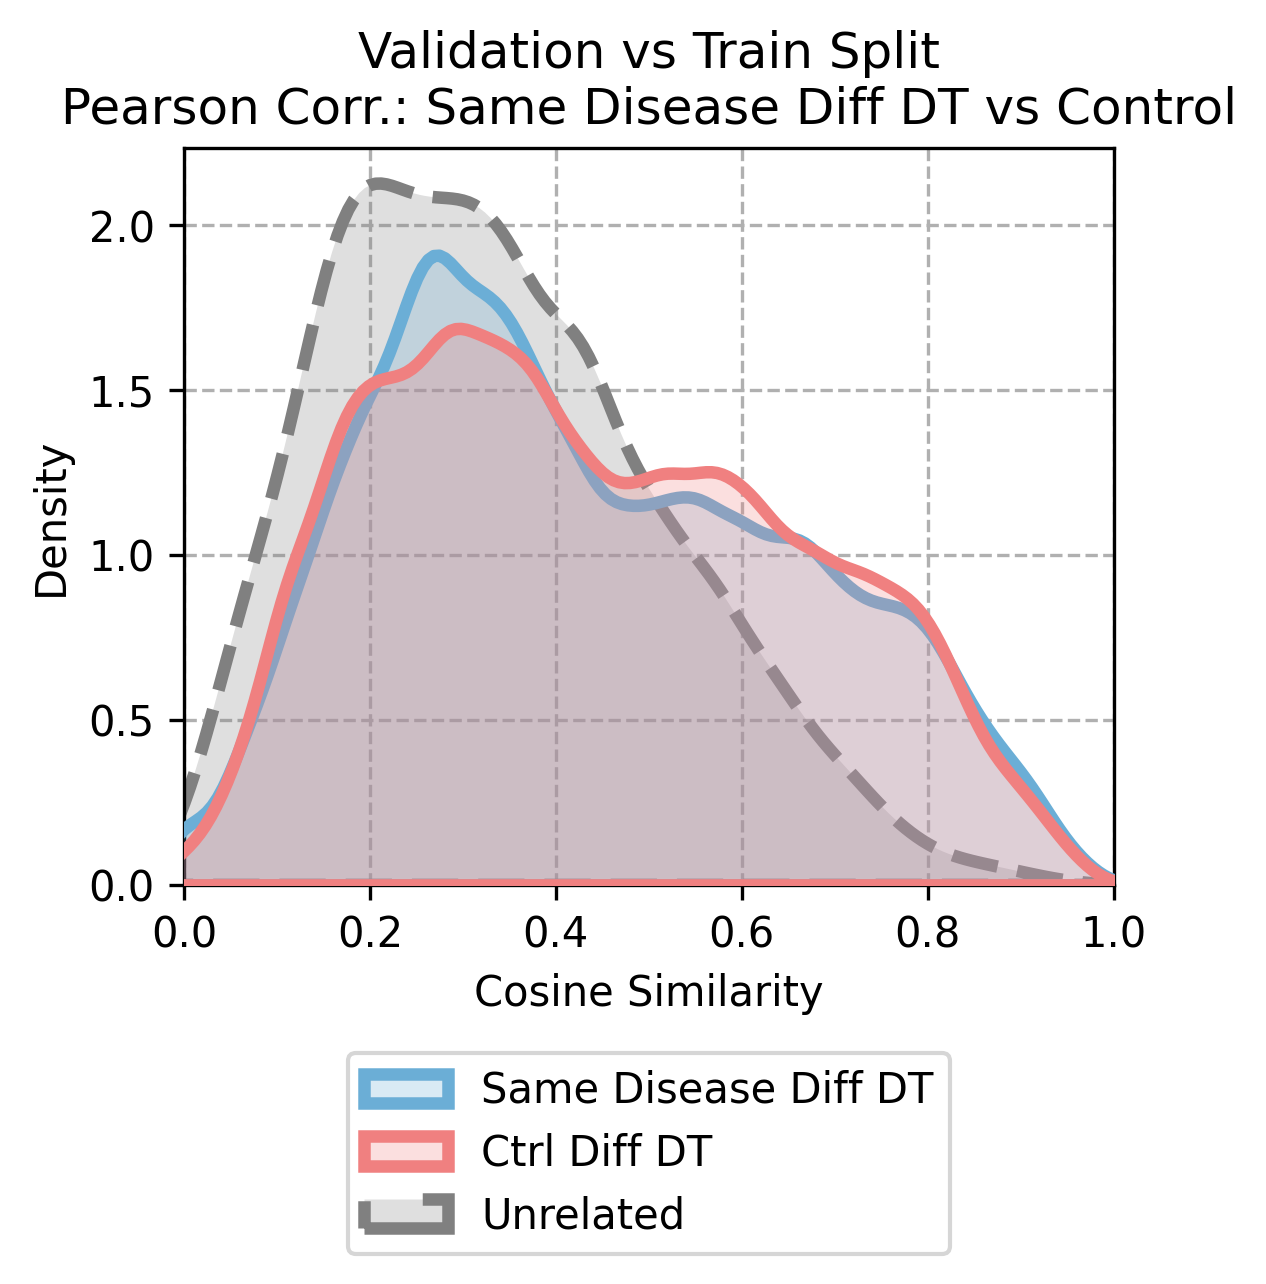

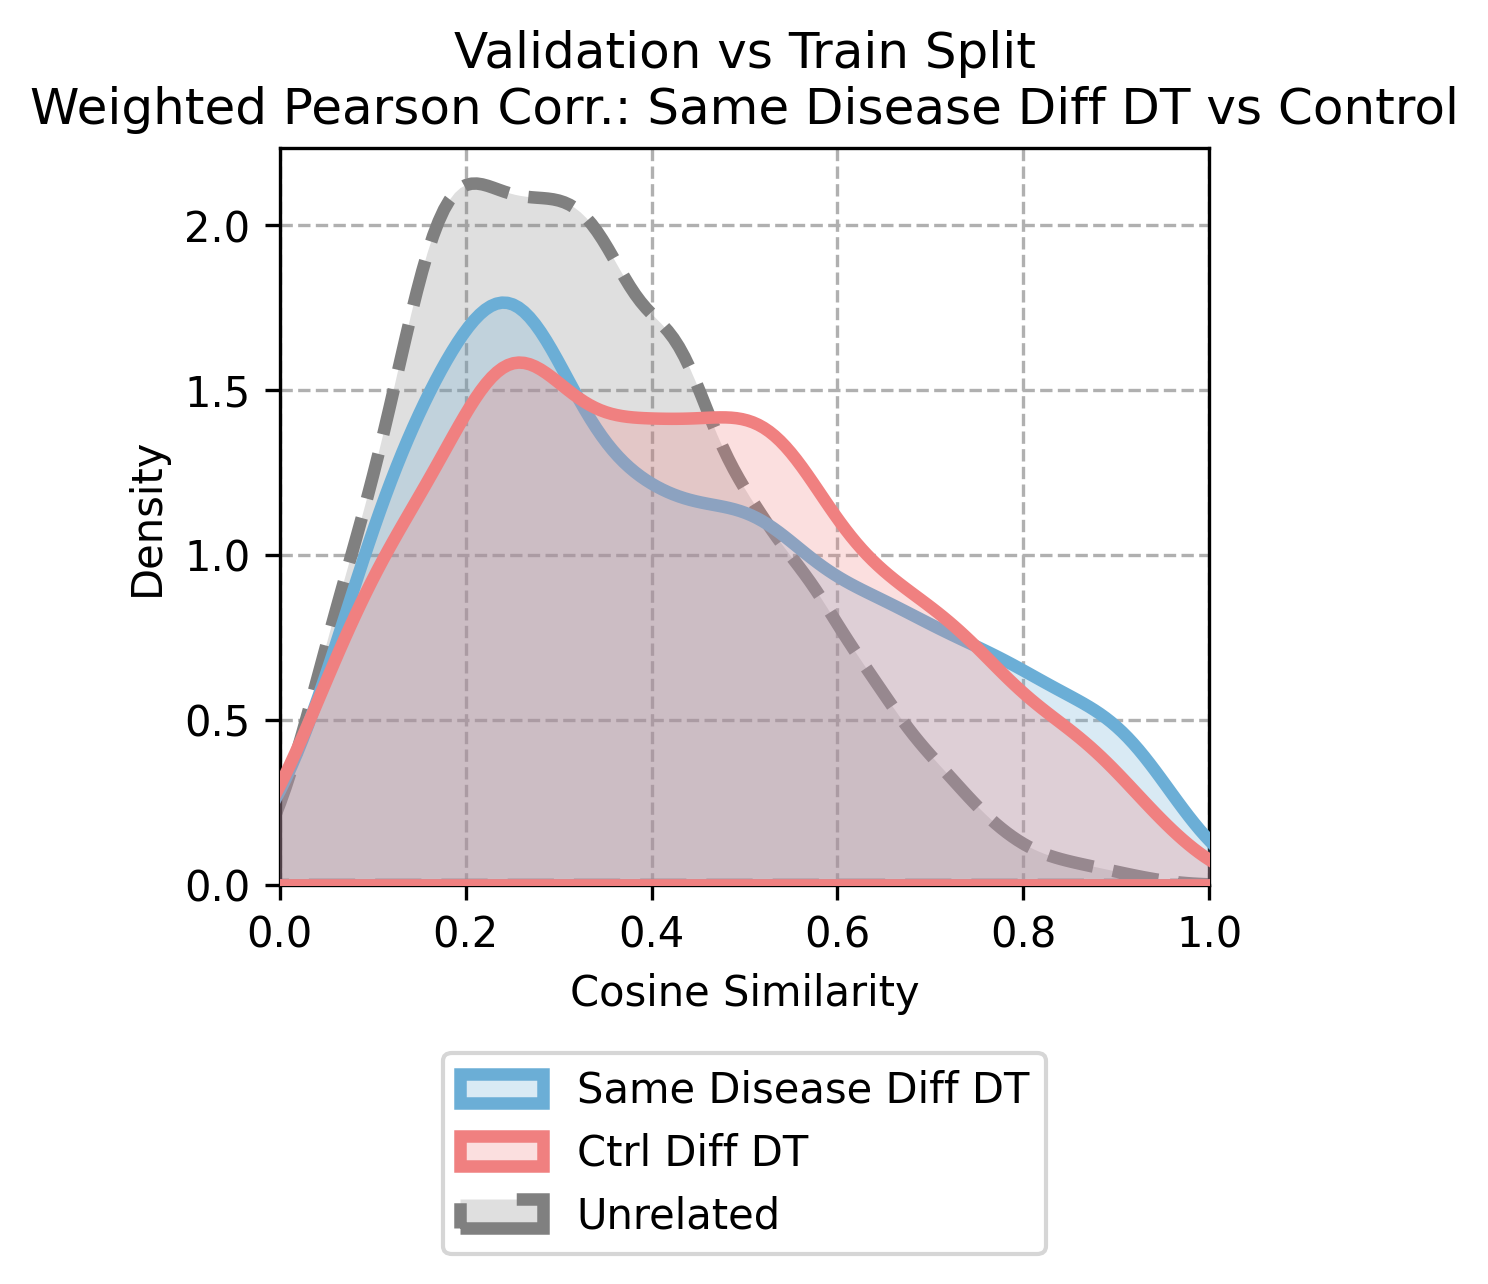

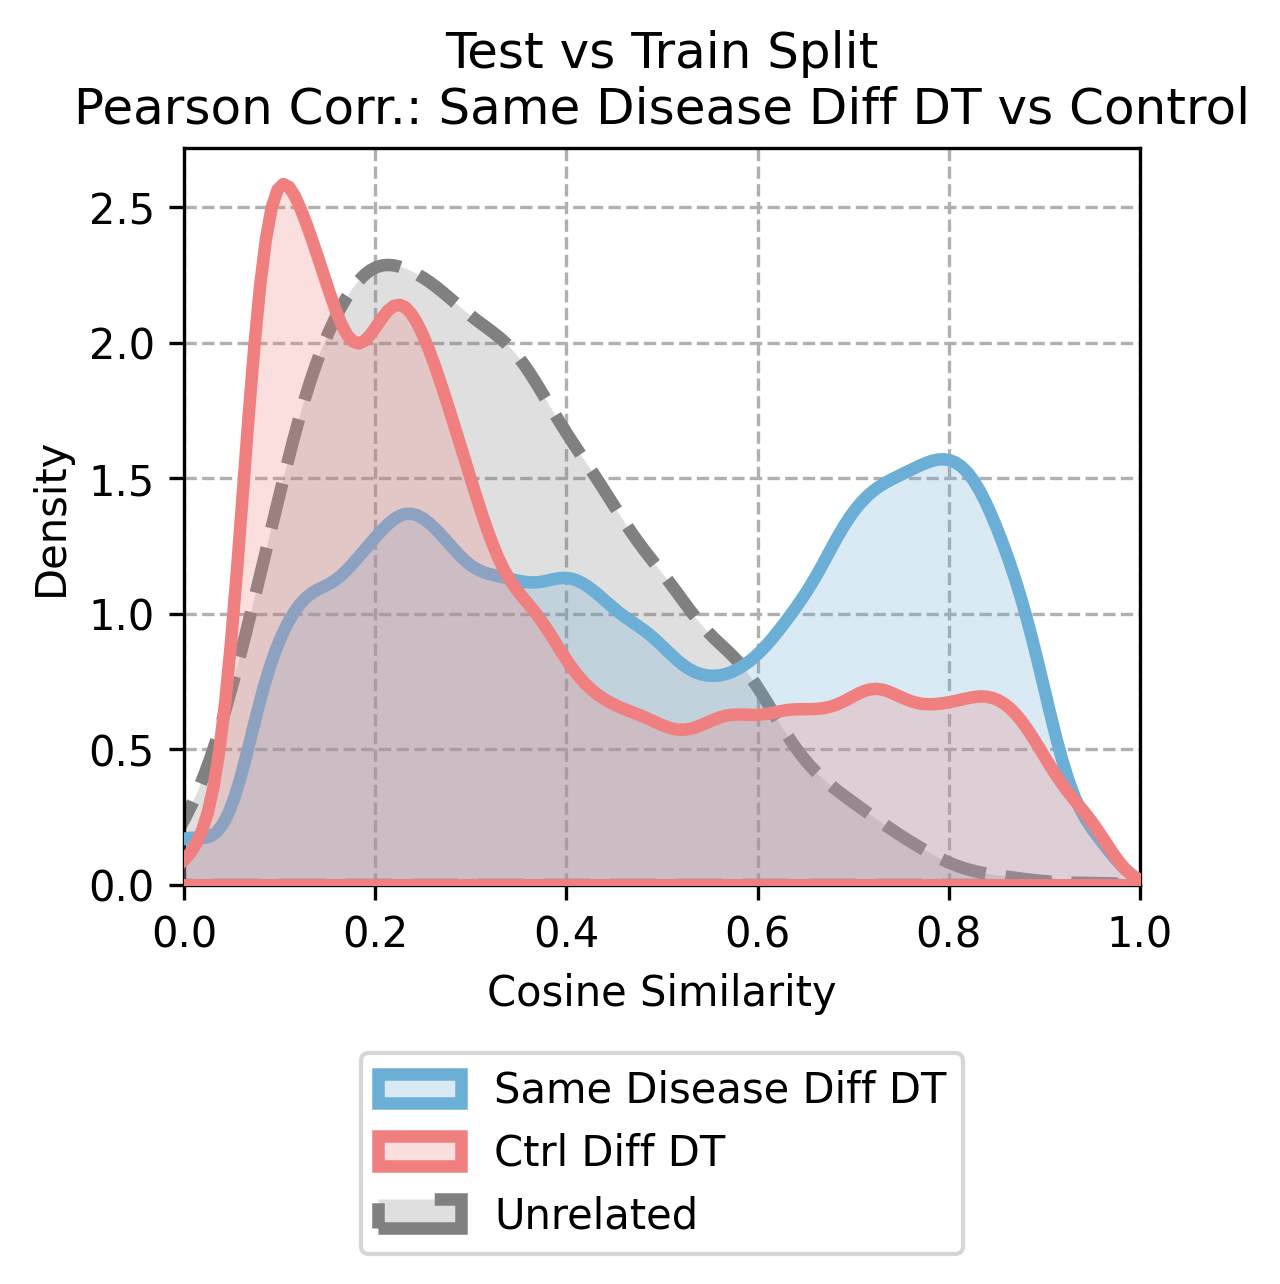

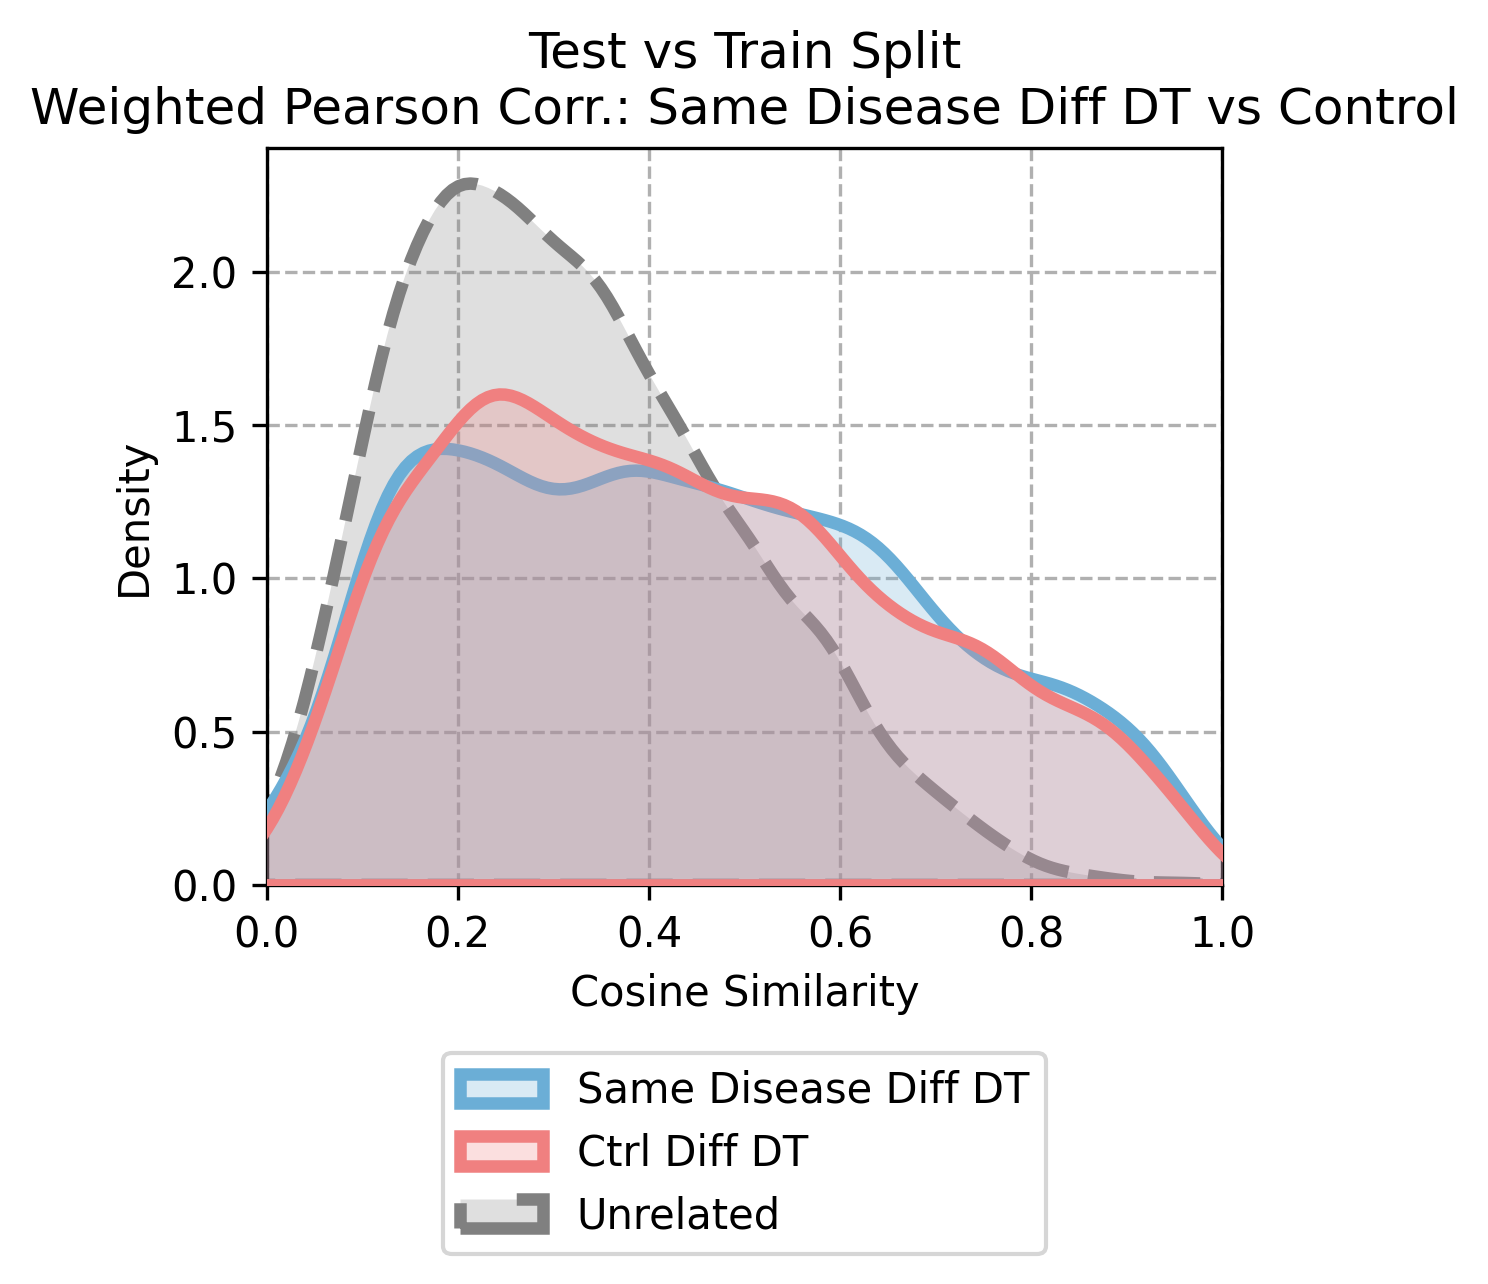

In [8]:
# 3. Plot Similarity
dpi_val = 300
# train
# unweighted
vz.plot_kde([tr_s_same_same, tr_s_same_diff, tr_s_ctrl_same, tr_s_ctrl_diff, tr_s_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Train Split\nPearson Corr.: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],dpi=dpi_val,
             weights=None, output_dir=os.path.join(output_dir, "gex_kde_train_dis_id.png"), x_lim_val=(0,1))

# weighted
vz.plot_kde([tr_s_same_same, tr_s_same_diff, tr_s_ctrl_same, tr_s_ctrl_diff, tr_s_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Train Split\nWeighted Pearson Corr.: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],
             weights=[tr_w_same_same, tr_w_same_diff, tr_w_ctrl_same, tr_w_ctrl_diff, None],output_dir=os.path.join(output_dir, "gex_kde_train_dis_id_w.png"),dpi=dpi_val, x_lim_val=(0,1))




# validation set
# unweighted
vz.plot_kde([vl_s_same_diff, vl_s_ctrl_diff, vl_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Validation vs Train Split\nPearson Corr.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],dpi=dpi_val,
             weights=None, output_dir=os.path.join(output_dir, "gex_kde_val_dis_id.png"), x_lim_val=(0,1))

# weighted
vz.plot_kde([vl_s_same_diff, vl_s_ctrl_diff, vl_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Validation vs Train Split\nWeighted Pearson Corr.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],
             weights=[vl_w_same_diff, vl_w_ctrl_diff, None],dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_val_dis_id_w.png"), x_lim_val=(0,1))


# test set
# unweighted
vz.plot_kde([ts_s_same_diff, ts_s_ctrl_diff, ts_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Test vs Train Split\nPearson Corr.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],dpi=dpi_val,
             weights=None, output_dir=os.path.join(output_dir, "gex_kde_test_dis_id.png"), x_lim_val=(0,1))

# weighted
vz.plot_kde([ts_s_same_diff, ts_s_ctrl_diff, ts_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Test vs Train Split\nWeighted Pearson Corr.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],
             weights=[ts_w_same_diff, ts_w_ctrl_diff, None],dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_test_dis_id_w.png"), x_lim_val=(0,1))


# 3. Benchmark Disease Related Disease Similarity

## 3.1 Plot KDE & AUROC

In [22]:
"""Benchmark Disease Related Disease Similarity

Structure:
    1. Imports, Variables, Functions
    2. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports
import random

# variables
sample_size = 10000

# functions
def get_bins(vals, bins):

    """
    Get the bin for each value in vals based on the provided bins.
    """
    bin_list = list()
    for val in vals:
        for i in range(len(bins) - 1):
            if bins[i] <= val < bins[i + 1]:
                bin_list.append((f"{bins[i]}-{bins[i + 1]}"))
                break
    return bin_list


# 2. Plot Similarity

# Type 1: Plot similarity based on semantic similarity
# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# bin data based on similarity
_bins = get_bins(do_df_ic_query["lin"].values,[0,0.2,0.4,0.6,0.8,1])
_bin_labels = ["'0.8-1'","'0.6-0.8'","'0.4-0.6'"]

# add new label to dataframe
df_related = df_related.copy()
df_related["shortest_path_length"] = _bins


#! QUICK FIX ! SOME NAN VALUES 
c_matrix_test_ = np.where(np.isnan(c_matrix_test), 0, c_matrix_test)
c_matrix_train_ = np.where(np.isnan(c_matrix_train), 0, c_matrix_train)
c_matrix_valid_ = np.where(np.isnan(c_matrix_valid), 0, c_matrix_valid)
c_matrix_test_vs_train_ = np.where(np.isnan(c_matrix_test_vs_train), 0, c_matrix_test_vs_train)
c_matrix_valid_vs_train_ = np.where(np.isnan(c_matrix_valid_vs_train), 0, c_matrix_valid_vs_train)


# train
tr_s_all_1, tr_w_all_1, tr_l_all_1 = vz.get_related_dis_sim(
    adata_train, c_matrix_train_, df_related, df_unrelated, labels=_bin_labels, sample=sample_size,
)

# valid
vl_s_all_1, vl_w_all_1, vl_l_all_1 = vz.get_related_dis_sim_splits(
    adata_valid, adata_train, c_matrix_valid_vs_train_, df_related, df_unrelated, labels=_bin_labels, sample=sample_size)

# test
ts_s_all_1, ts_w_all_1, ts_l_all_1 = vz.get_related_dis_sim_splits(
    adata_test, adata_train, c_matrix_test_vs_train_, df_related, df_unrelated, labels=_bin_labels, sample=sample_size)




# Type 2: Plot similarity based on DO graph distance
# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

labels = [2, 3, 5]  # define labels


# train
tr_s_all_2, tr_w_all_2, tr_l_all_2 = vz.get_related_dis_sim(
    adata_train, c_matrix_train_, df_related, df_unrelated, labels, sample=sample_size,
)

# valid
vl_s_all_2, vl_w_all_2, vl_l_all_2 = vz.get_related_dis_sim_splits(
    adata_valid, adata_train, c_matrix_valid_vs_train_, df_related, df_unrelated, labels, sample=sample_size)

# test
ts_s_all_2, ts_w_all_2, ts_l_all_2 = vz.get_related_dis_sim_splits(
    adata_test, adata_train, c_matrix_test_vs_train_, df_related, df_unrelated, labels, sample=sample_size)


100%|██████████| 7500/7500 [00:02<00:00, 3237.58it/s]


Nº of unrelated disease pairs: 62959869
[SP '0.8-1'] Nº of related disease pairs: 58


100%|██████████| 58/58 [00:01<00:00, 56.98it/s]


Nº of related disease pairs for '0.8-1': 468734
[SP '0.6-0.8'] Nº of related disease pairs: 169


100%|██████████| 169/169 [00:05<00:00, 30.81it/s]


...

Nº of related disease pairs for 3: 5767012
[SP 5] Nº of related disease pairs: 151


100%|██████████| 151/151 [00:05<00:00, 27.91it/s]


Nº of related disease pairs for 5: 2479973
Nº of diseases: 130


100%|██████████| 130/130 [00:01<00:00, 94.25it/s] 


Nº of unrelated disease pairs: 5767012


In [24]:
np.isnan(c_matrix_test_).sum()

0

In [34]:
np.isnan(tr_s_all_1[4]).sum()

0

In [46]:
np.min(X_train)

0.0

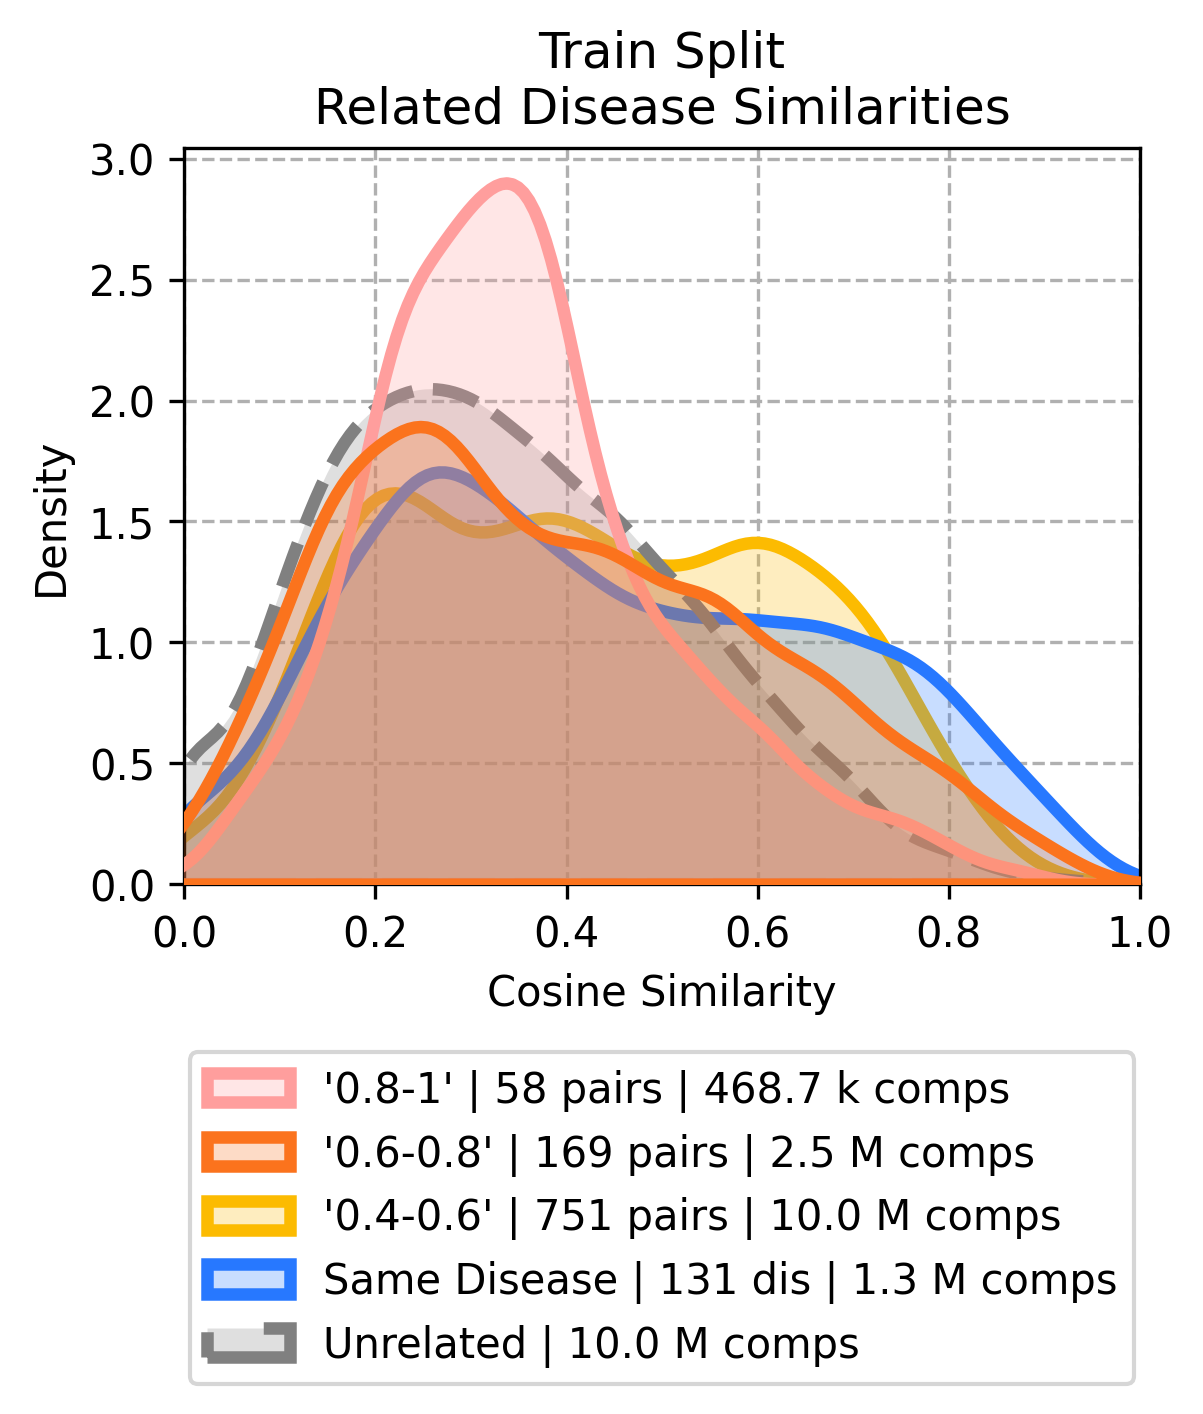

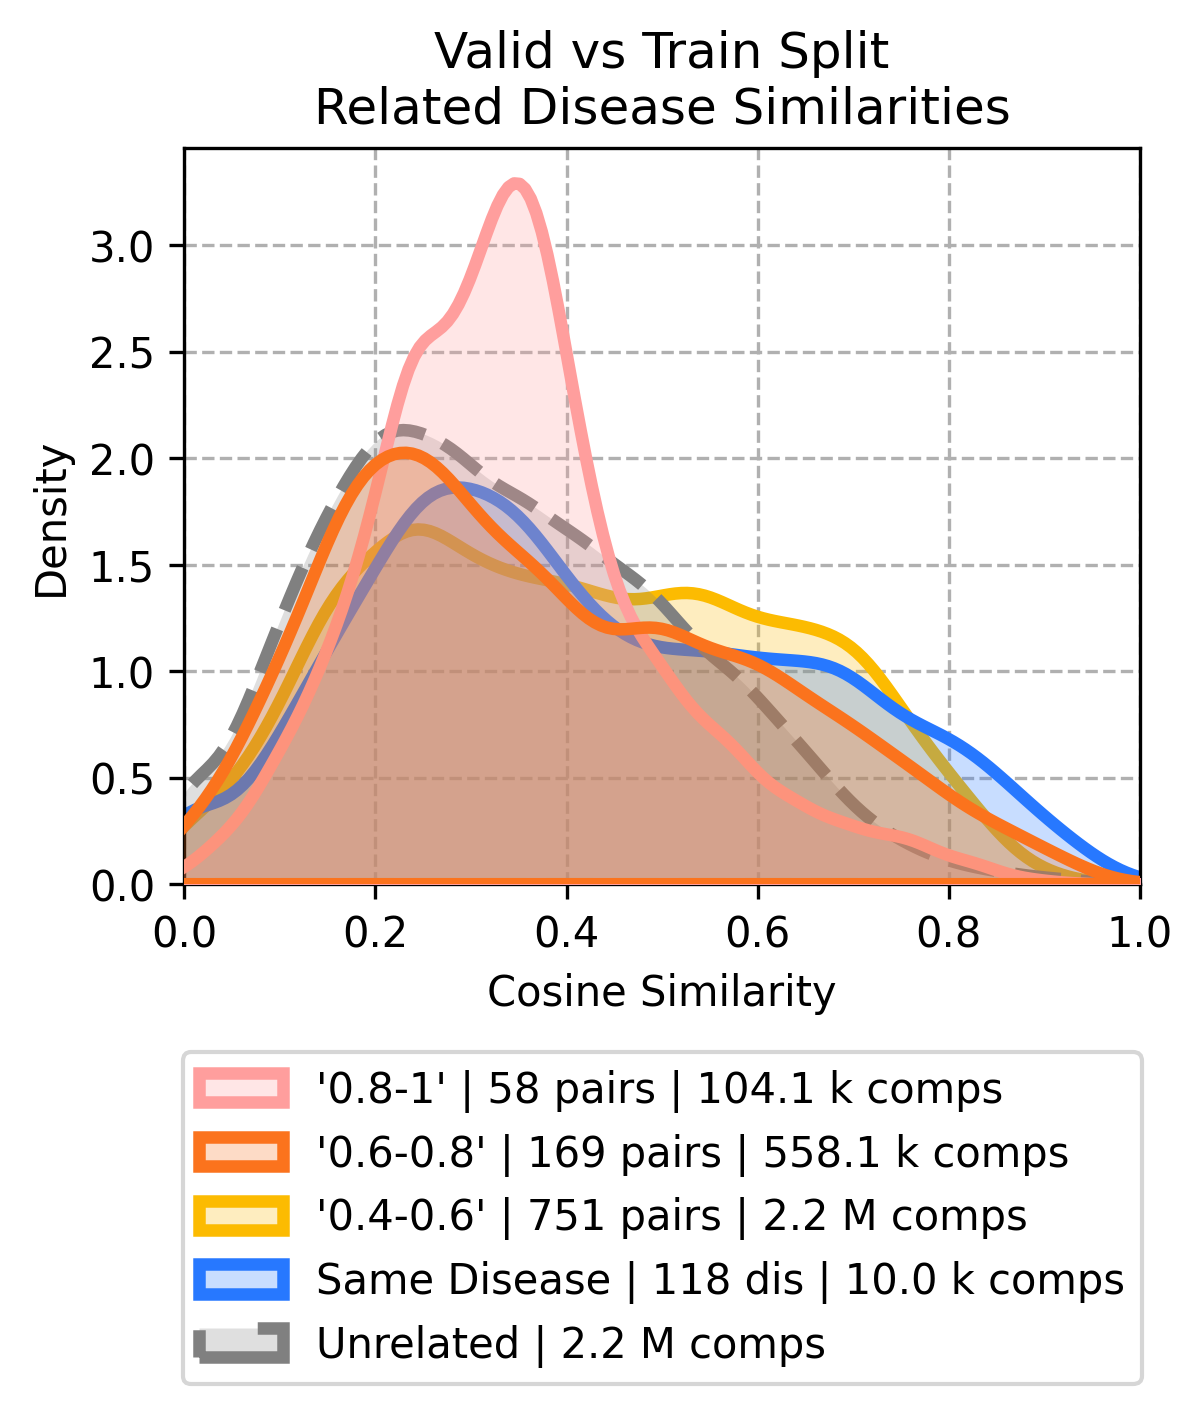

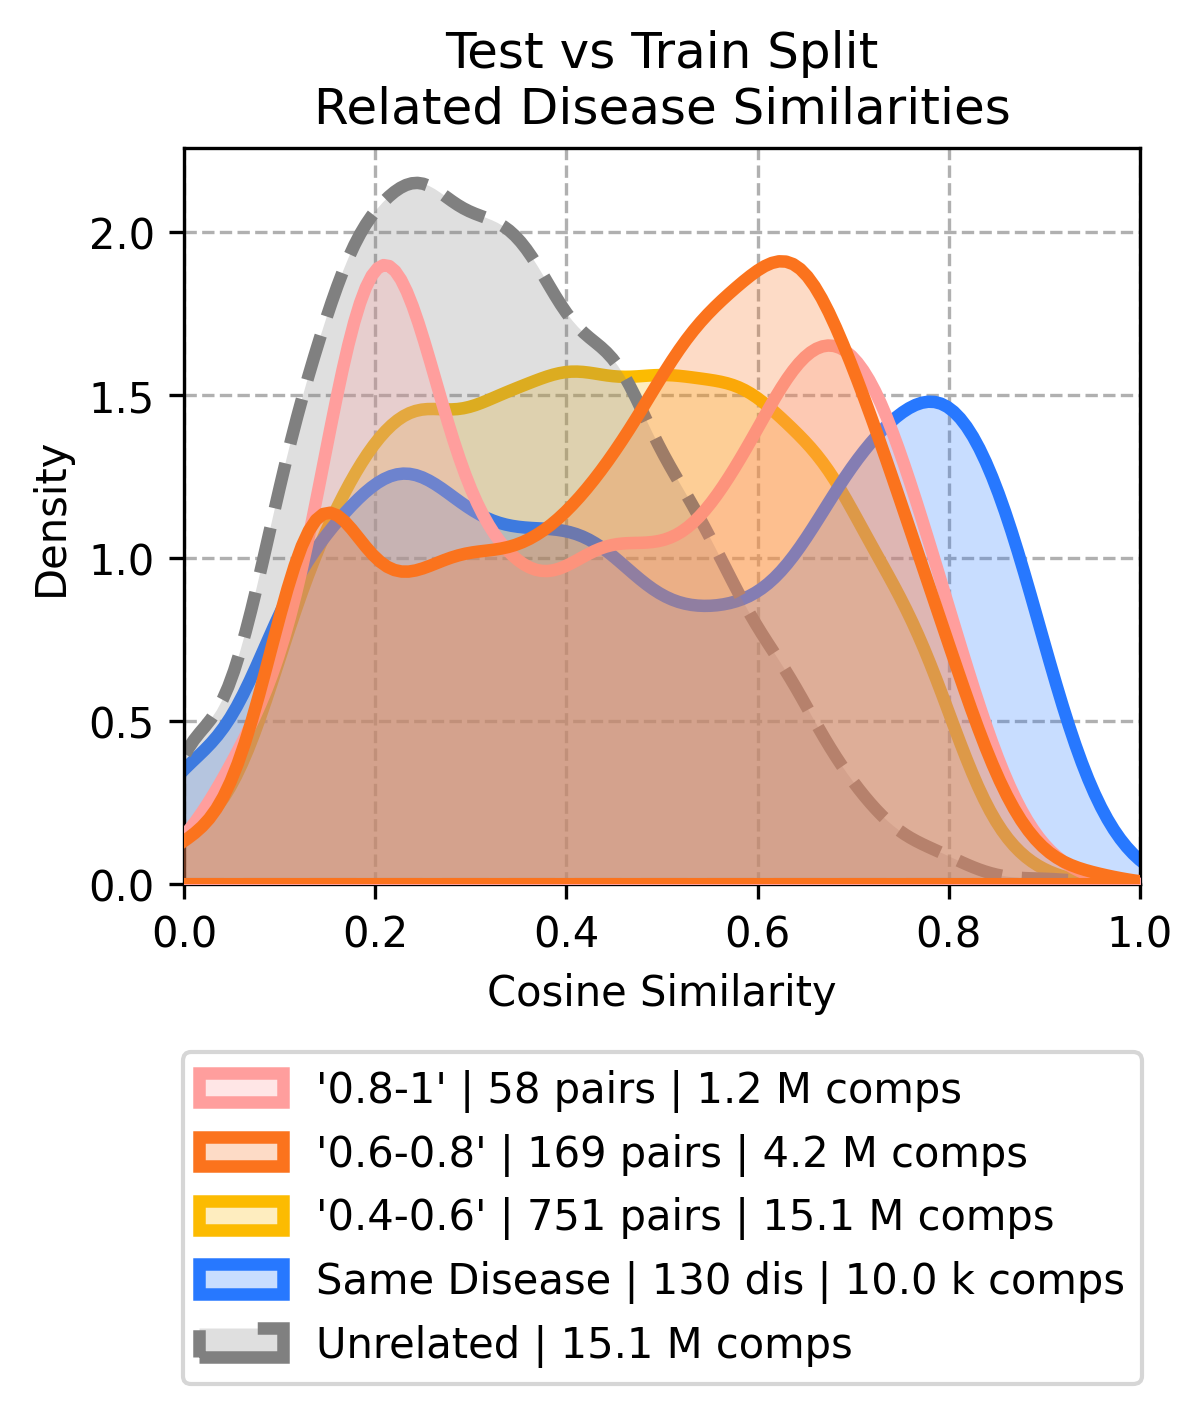

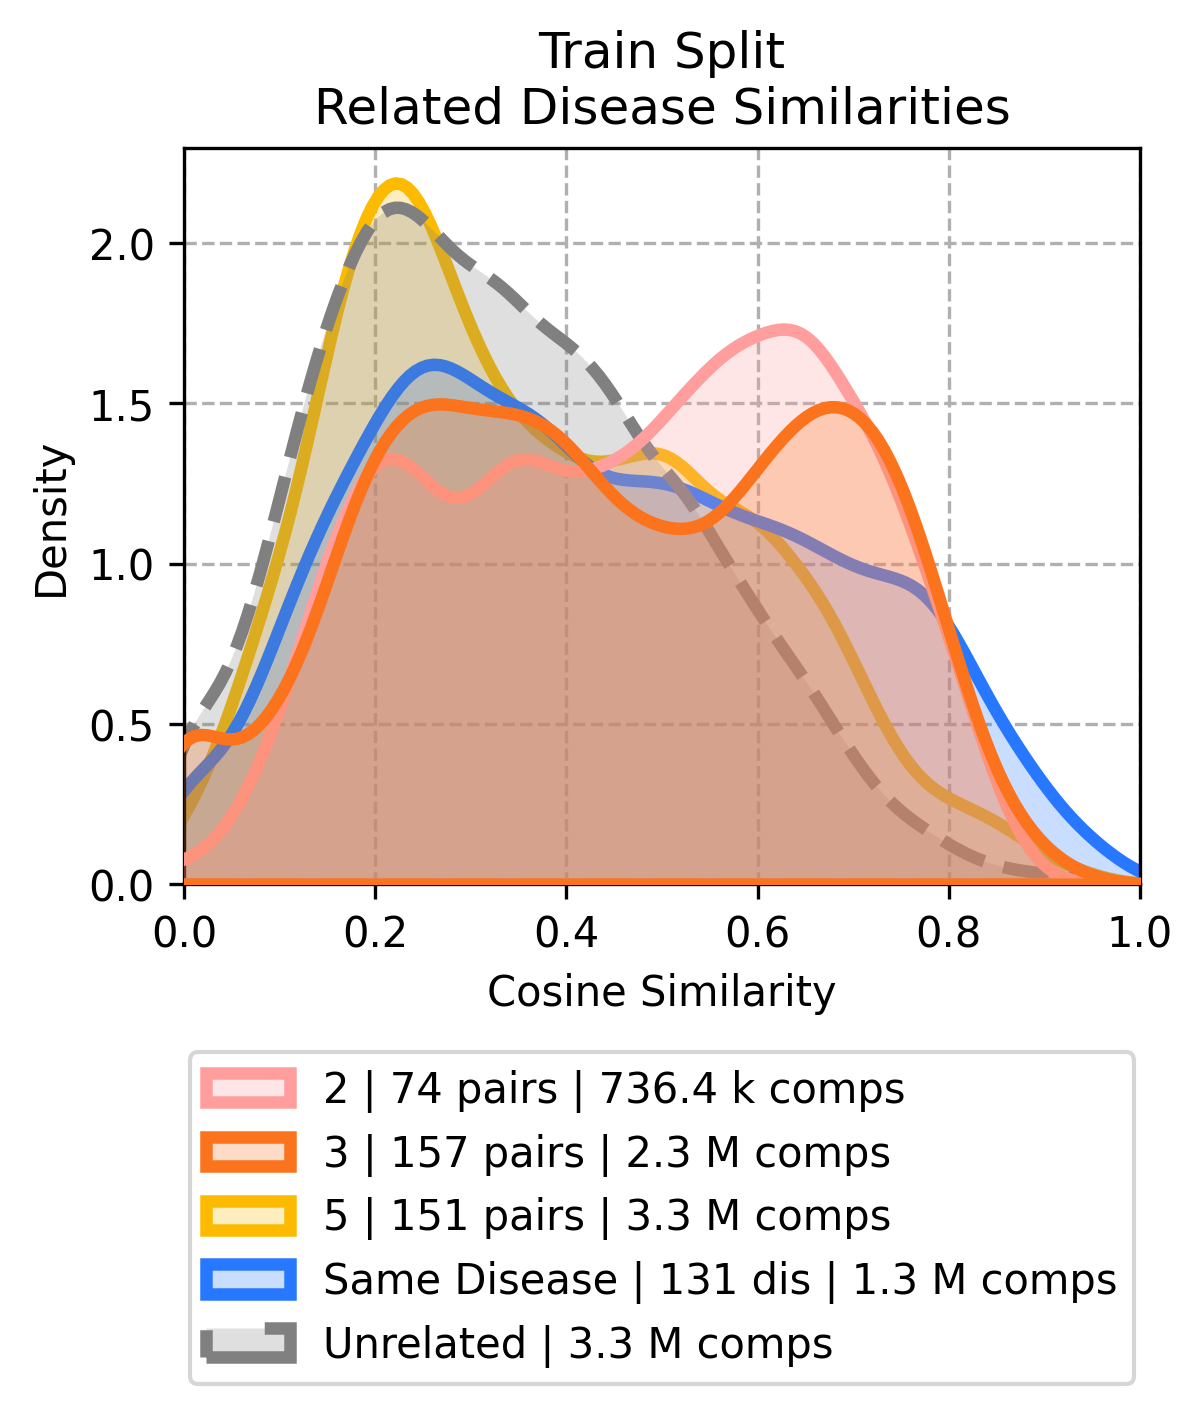

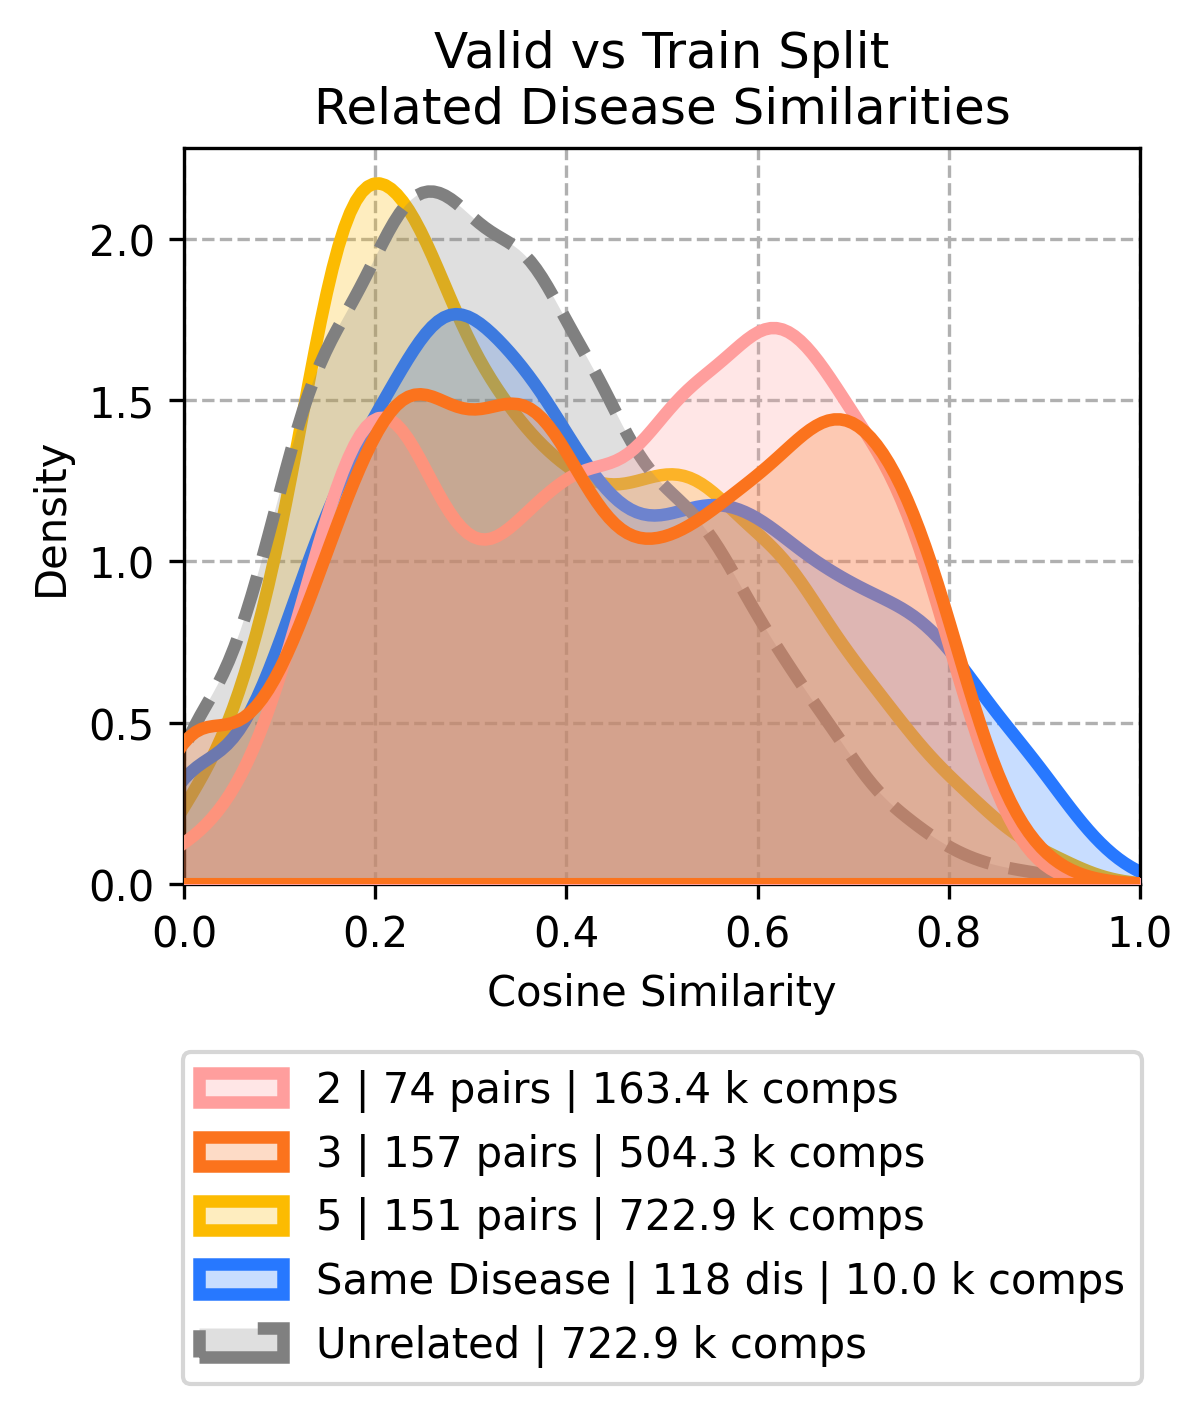

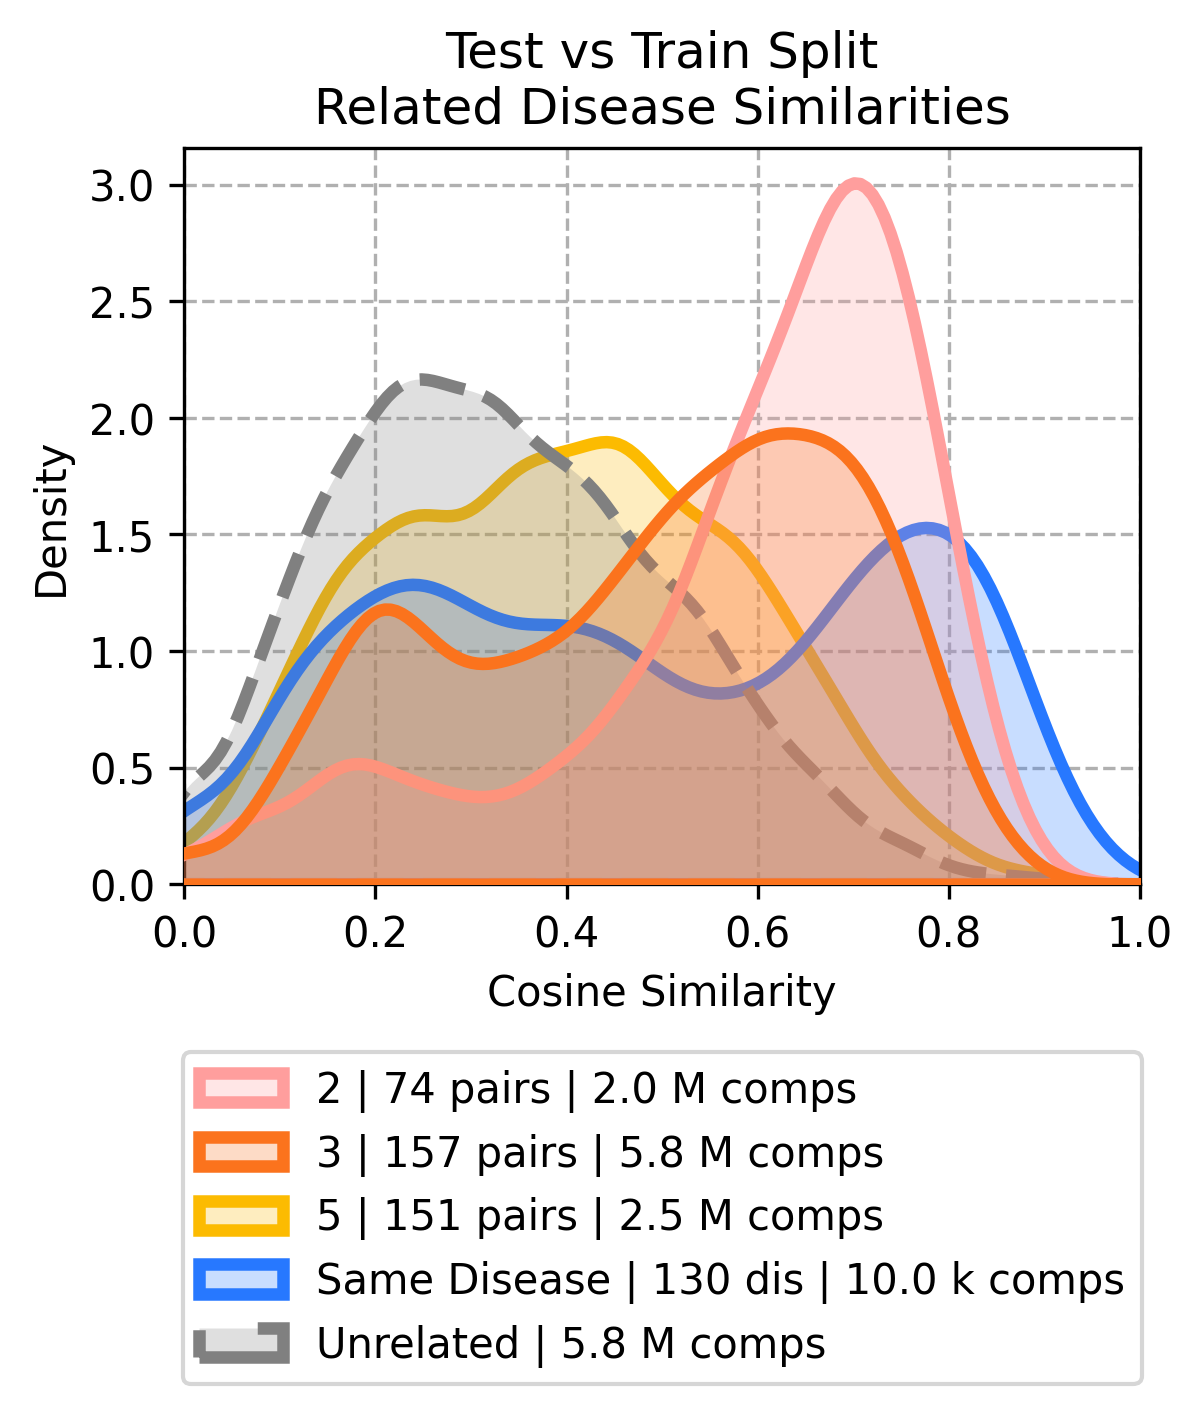

In [36]:

dpi_val = 300
colors_val=["#ff9e9d", "#fb731d", "#fcbb01","#2778ff","grey"]
# plot
# Type 1
# train
vz.plot_kde(tr_s_all_1, labels=tr_l_all_1, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_train_1.png"))
#vz.plot_roc(tr_s_all_1[:-1], tr_s_unr, labels=tr_l_all_1, title="Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_train_1.png"))


# validation
vz.plot_kde(vl_s_all_1, labels=vl_l_all_1, colors=colors_val, title="Valid vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_valid_1.png"))
#vz.plot_roc(vl_s_all_1[:-1], vl_s_unr, labels=vl_l_all_1, title="Valid vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_valid_1.png"))

# test
vz.plot_kde(ts_s_all_1, labels=ts_l_all_1, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_test_1.png"))
#vz.plot_roc(ts_s_all_1[:-1], ts_s_unr, labels=ts_l_all_1, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_test_1.png"))

# Type 2
# train
vz.plot_kde(tr_s_all_2, labels=tr_l_all_2, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_train_2.png"))
#vz.plot_roc(tr_s_all_2[:-1], tr_s_unr, labels=tr_l_all_2, title="Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_train_2.png"))

# validation
vz.plot_kde(vl_s_all_2, labels=vl_l_all_2, colors=colors_val, title="Valid vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_valid_2.png"))
#vz.plot_roc(vl_s_all_2[:-1], vl_s_unr, labels=vl_l_all_2, title="Valid vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_valid_2.png"))

# test
vz.plot_kde(ts_s_all_2, labels=ts_l_all_2, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_kde_test_2.png"))
#vz.plot_roc(ts_s_all_2[:-1], ts_s_unr, labels=ts_l_all_2, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "gex_roc_test_2.png"))